In [20]:
%cd /home/wenke/SIMPLE
%pwd

from dotenv import load_dotenv
load_dotenv()

/home/wenke/SIMPLE


/home/wenke/SIMPLE/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


False

In [21]:
!uv pip install matplotlib

Audited 1 package in 4ms


In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# read the dict from the pickle file replay_0_debug_ctrl_err.pkl

import pickle
with open("control_0_debug_ctrl_err.pkl", "rb") as f:
    debug_ctrl_err = pickle.load(f)


In [24]:
for t, err in debug_ctrl_err.items():
    print(f"Time step {t}:")
    for jname, info in err.items():
        print(f"  Joint {jname}: target_q={info['target_q']}, current_q={info['current_q']}, torque={info['torque']}")
        break
    break

Time step 60:
  Joint right_hand_index_0_joint: target_q=0.0025434154085814953, current_q=0.0025434154252274694, torque=-0.0013436905721818475


In [25]:
from collections import defaultdict
control_errs = defaultdict(list)

for t, err in debug_ctrl_err.items():
    for jname, info in err.items():
        # control_errs[jname].append(info["target_q"] - info["final_q"])
        # control_errs[jname].append(info["current_q"] - info["final_q"])
        # print("right_hand_thumb_2_joint_torque")
        control_errs[f"{jname}_current_q"].append(info["current_q"])
        control_errs[f"{jname}_target_q"].append(info["target_q"])
        control_errs[f"{jname}_final_q"].append(info["final_q"])
        control_errs[f"{jname}_torque"].append(info["torque"])

In [26]:
# print(len(control_errs))
# print(control_errs.keys())
print(control_errs["right_hand_thumb_2_joint_torque"])

[-0.00011770995128824449, 0.000411284382721526, 0.00012105748669934671, -0.02801411128057613, -0.04681802081234471, -0.07443160903628557, -0.09102528591490358, -0.10427670297925895, -0.1137749182542912, -0.11602097532936284, -0.1243127913294717, -0.122842895849578, -0.1343403961998671, -0.13227185624549725, -0.14681389640152392, -0.14668364134636644, -0.15774277945721815, -0.1588844594968654, -0.16558634408962808, -0.16780550506352193, -0.17135595261582082, -0.1746813891774821, -0.17607773911963276, -0.1801054096920025, -0.17993910299143728, -0.18400084158825952, -0.1827236391847667, -0.18609649762274244, -0.1847480376654786, -0.1859983845731243, -0.18483289432354688, -0.18409330358942277, -0.18287347712861668, -0.18103362282214852, -0.17935554175065915, -0.17702226181966468, -0.17423203841105783, -0.17190234209621708, -0.1673462367266212, -0.16556743247832734, -0.1587458225480174, -0.15737425498099356, -0.14889828964588647, -0.14672070394033815, -0.13852334563855984, -0.13488457259569

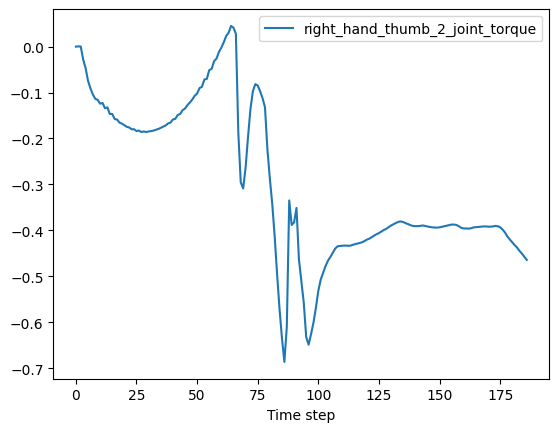

In [27]:

# plt.plot(np.rad2deg(control_errs["right_hand_thumb_2_joint_current_q"]), label="right_hand_thumb_2_joint_current_q")
# plt.plot(np.rad2deg(control_errs["right_hand_thumb_2_joint_target_q"]), label="right_hand_thumb_2_joint_target_q")
# plt.plot(np.rad2deg(control_errs["right_hand_thumb_2_joint_final_q"]), label="right_hand_thumb_2_joint_final_q")
plt.plot(control_errs["right_hand_thumb_2_joint_torque"], label="right_hand_thumb_2_joint_torque")
plt.legend()
plt.xlabel("Time step")
plt.show()

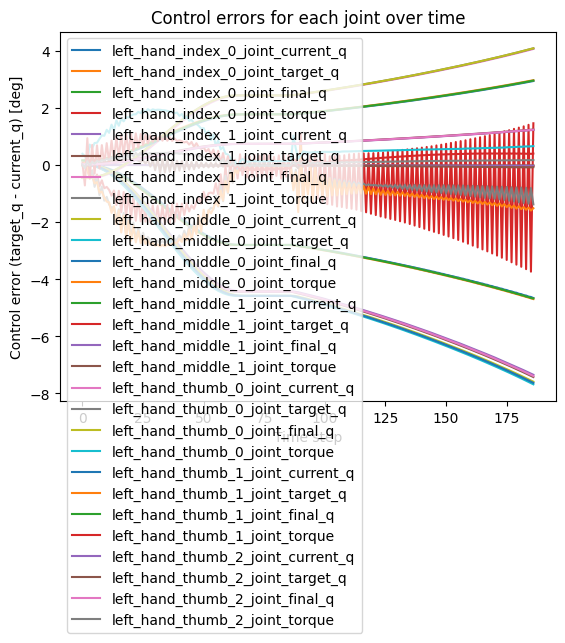

In [28]:

for jname, errs in control_errs.items():
    # if jname == "left_hand_thumb_0_joint":
    if "left" in jname:
        plt.plot(np.rad2deg(errs), label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()


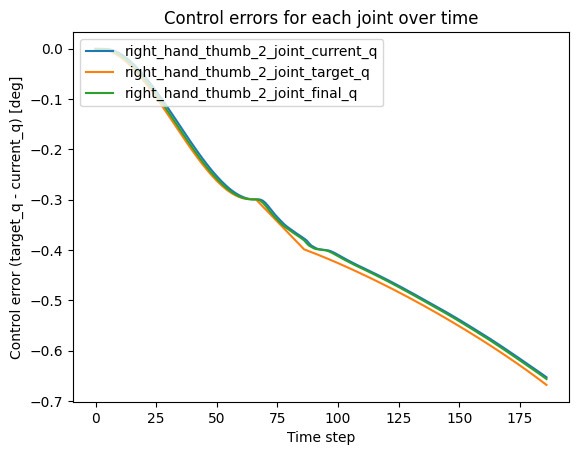

In [29]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_thumb_2_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()


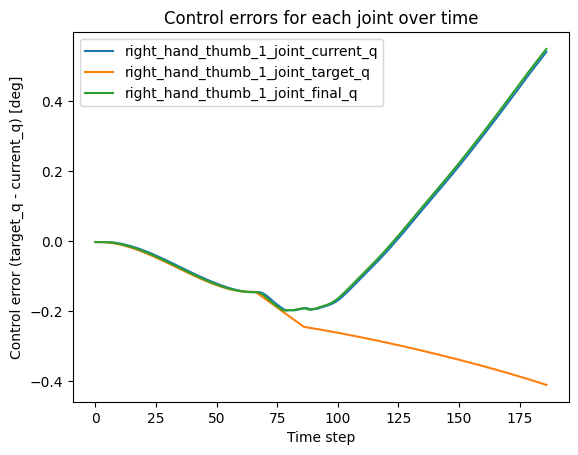

In [30]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_thumb_1_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

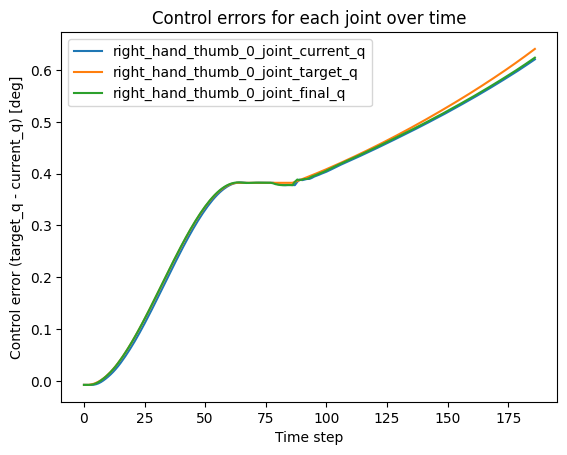

In [31]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_thumb_0_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

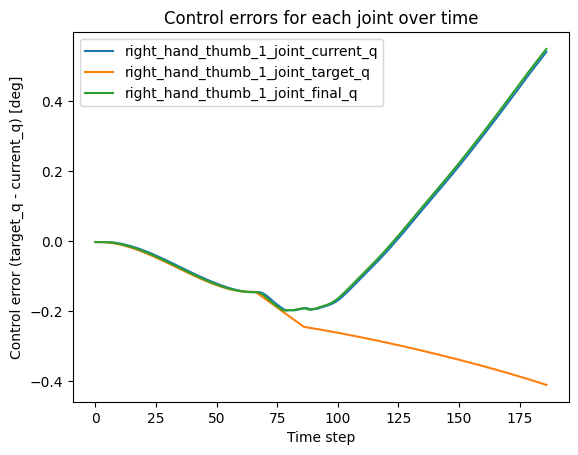

In [32]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_thumb_1_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

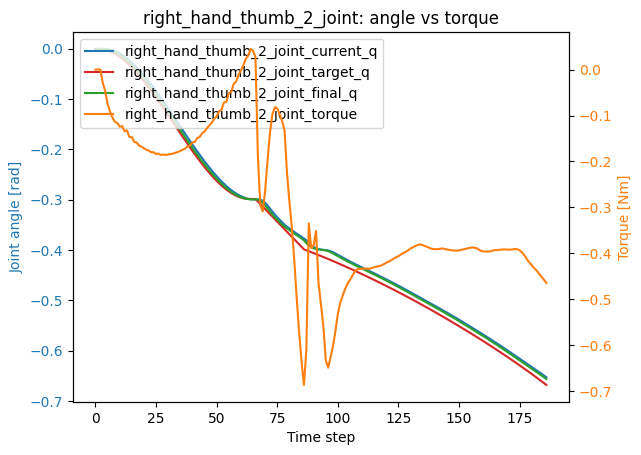

In [33]:
# import numpy as np
# # plot a line chart of control errors for each joint
# import matplotlib.pyplot as plt
# for jname, errs in control_errs.items():
#     if "right_hand_thumb_2_joint" in jname:
#         # if "torque" not in jname:
#             plt.plot(errs, label=jname)
# plt.legend(loc="upper left")
# plt.xlabel("Time step")
# plt.ylabel("Joint angle [rad]")
# plt.title("Control errors for each joint over time")
# plt.show()

import matplotlib.pyplot as plt

joint = "right_hand_thumb_2_joint"

# angle_key = f"{joint}_current_q"
torque_key = f"{joint}_torque"

fig, ax1 = plt.subplots()
ax1.plot(control_errs[f"{joint}_current_q"], color="tab:blue", label=f"{joint}_current_q")
ax1.plot(control_errs[f"{joint}_target_q"], color="tab:red", label=f"{joint}_target_q")
ax1.plot(control_errs[f"{joint}_final_q"], color="tab:green", label=f"{joint}_final_q")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Joint angle [rad]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(control_errs[torque_key], color="tab:orange", label=torque_key)
ax2.set_ylabel("Torque [Nm]", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Combine legends from both axes
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(f"{joint}: angle vs torque")
plt.show()

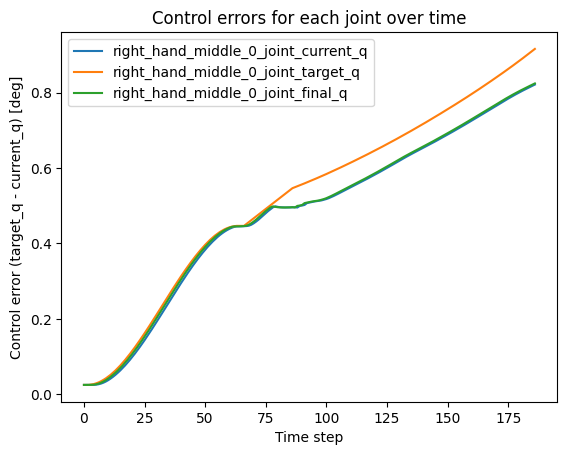

In [34]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_middle_0_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

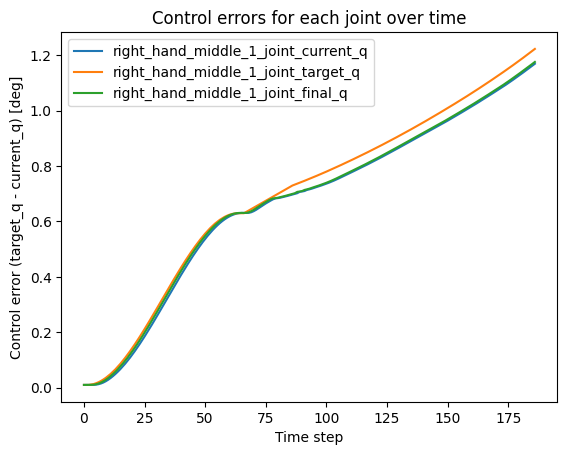

In [35]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_middle_1_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

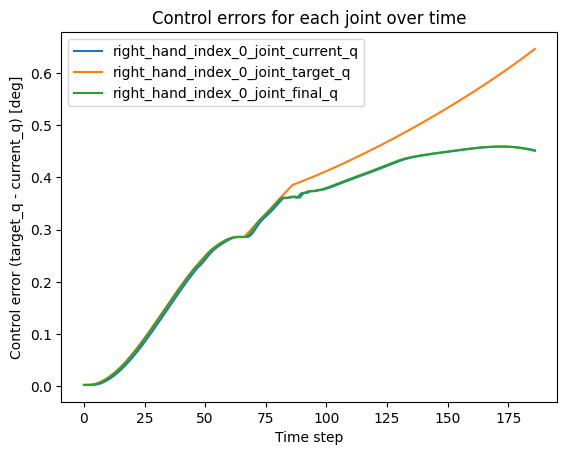

In [36]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_index_0_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

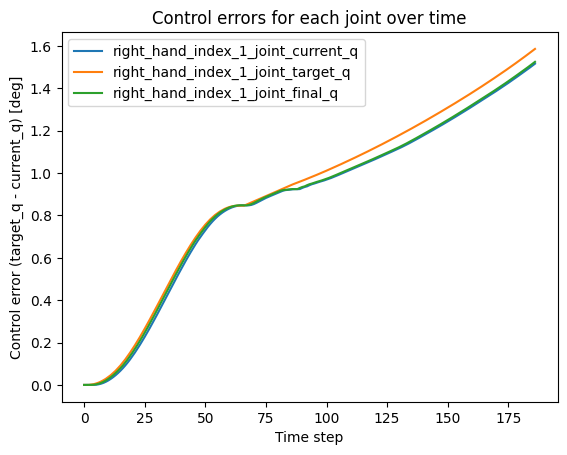

In [37]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "right_hand_index_1_joint" in jname:
        if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()

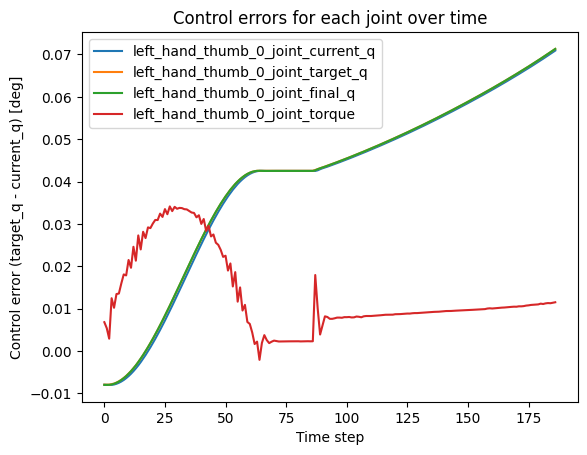

In [38]:
import numpy as np
# plot a line chart of control errors for each joint
import matplotlib.pyplot as plt
for jname, errs in control_errs.items():
    if "left_hand_thumb_0_joint" in jname:
        # if "torque" not in jname:
            plt.plot(errs, label=jname)
plt.legend(loc="upper left")
plt.xlabel("Time step")
plt.ylabel("Control error (target_q - current_q) [deg]")
plt.title("Control errors for each joint over time")
plt.show()